#### Import libraries

In [94]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#### Load dataset and checking null values

In [95]:
df = pd.read_csv("spam.csv",encoding="Windows-1252")

null_values = df.isnull().sum() / len(df) * 100
null_values = null_values.sort_values(ascending=False)
print(f"Null values are : \n{null_values}")


Null values are : 
Unnamed: 4    99.892319
Unnamed: 3    99.784637
Unnamed: 2    99.102656
v1             0.000000
v2             0.000000
dtype: float64


#### Transform datasets

In [96]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

df.rename(columns={'v1': 'label', 'v2': 'text'}, inplace=True)

print(df["label"].unique())
dict = {"ham":1,"spam":0}
df['label'] = df['label'].map(dict)
df.head()

['ham' 'spam']


,label,text
0,1,"Go until jurong point, crazy.. Available only ..."
1,1,Ok lar... Joking wif u oni...
2,0,Free entry in 2 a wkly comp to win FA Cup fina...
3,1,U dun say so early hor... U c already then say...
4,1,"Nah I don't think he goes to usf, he lives aro..."


##### Split dataset

In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42)

#### Tokenization

In [98]:
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.9)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

### Model fit

In [99]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)


#### Evaluation


--- Model Evaluation ---
Accuracy: 0.9668


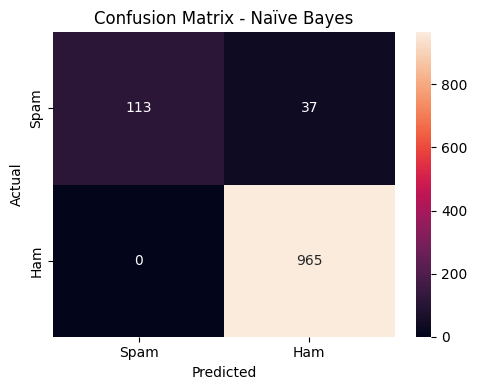

In [100]:
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket', xticklabels=['Spam', 'Ham'], yticklabels=['Spam', 'Ham'])
plt.title("Confusion Matrix - Naïve Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



##### Classification report


Classification Report:

              precision    recall  f1-score   support

        Spam       1.00      0.75      0.86       150
         Ham       0.96      1.00      0.98       965

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



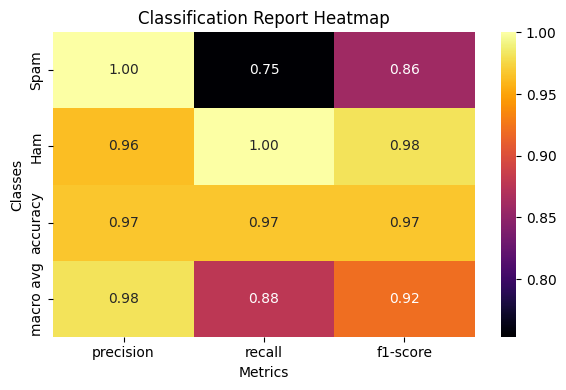

In [101]:
report = classification_report(y_test, y_pred, output_dict=True, target_names=['Spam', 'Ham'])
report_df = pd.DataFrame(report).transpose()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Spam', 'Ham']))

plt.figure(figsize=(6, 4))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='inferno', fmt='.2f')
plt.title("Classification Report Heatmap")
plt.xlabel("Metrics")
plt.ylabel("Classes")
plt.tight_layout()
plt.show()